In [29]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Uploading the data

In [ ]:
staff = pd.read_csv(r"staff_master.csv")
grades = pd.read_csv(r"grade_salaries.csv")

# Merging the two data set
df = staff.merge(grades, on='grade', how='left')

In [31]:
df.info()          # Check data types, missing values
df.describe()      # Check numeric columns (salary)
df[['gender','ethnicity','department','grade']].nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   staff_id             6000 non-null   object 
 1   department           6000 non-null   object 
 2   grade                6000 non-null   object 
 3   contract_type        6000 non-null   object 
 4   fte                  6000 non-null   float64
 5   start_date           6000 non-null   object 
 6   last_promotion_date  937 non-null    object 
 7   gender               6000 non-null   object 
 8   ethnicity            6000 non-null   object 
 9   exit_date            899 non-null    object 
 10  salary               5898 non-null   float64
dtypes: float64(2), object(9)
memory usage: 515.8+ KB


gender         5
ethnicity      5
department    15
grade         20
dtype: int64

In [32]:
df.head()          # See a sample

,staff_id,department,grade,contract_type,fte,start_date,last_promotion_date,gender,ethnicity,exit_date,salary
0,S00001,Sales,G4,Fixed-term,1.00,2019-10-07,NaN,Male,White,2022-02-17,28500.0
1,S00002,IT Services,G6,Permanent,1.00,2013-10-29,NaN,Male,White,NaN,42000.0
2,S00003,Sales,G4,Fixed-term,0.82,2010-07-14,NaN,Female,White,2018-03-31,28500.0
3,S00004,Customer Services,G6,Permanent,1.00,2018-07-05,NaN,Male,Other,NaN,42000.0
4,S00005,HR,G4,Permanent,1.00,2014-11-22,2019-11-21,Female,White,NaN,28500.0


In [33]:
df.isna().sum()

staff_id                  0
department                0
grade                     0
contract_type             0
fte                       0
start_date                0
last_promotion_date    5063
gender                    0
ethnicity                 0
exit_date              5101
salary                  102
dtype: int64

In [34]:
# checking what percentage of it is missing
df['salary'].isnull().mean() * 100


np.float64(1.7000000000000002)

In [35]:
# dropping the empty rows
df = df.dropna(subset=['salary'])


In [36]:
# capitalizing 
df['gender'] = df['gender'].str.title().str.strip() 
df['ethnicity'] = df['ethnicity'].str.title().str.strip()
df['department'] = df['department'].str.title().str.strip()


In [ ]:
# changing the F and M to Male and Female
df['gender'] = df['gender'].replace({
    'F': 'Female',
    'M': 'Male'
})

In [37]:
# Convert salary column to numeric; any non-numeric values will be set to NaN
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')

In [41]:
print(df['gender'].unique())


['Male' 'Female' 'Other']


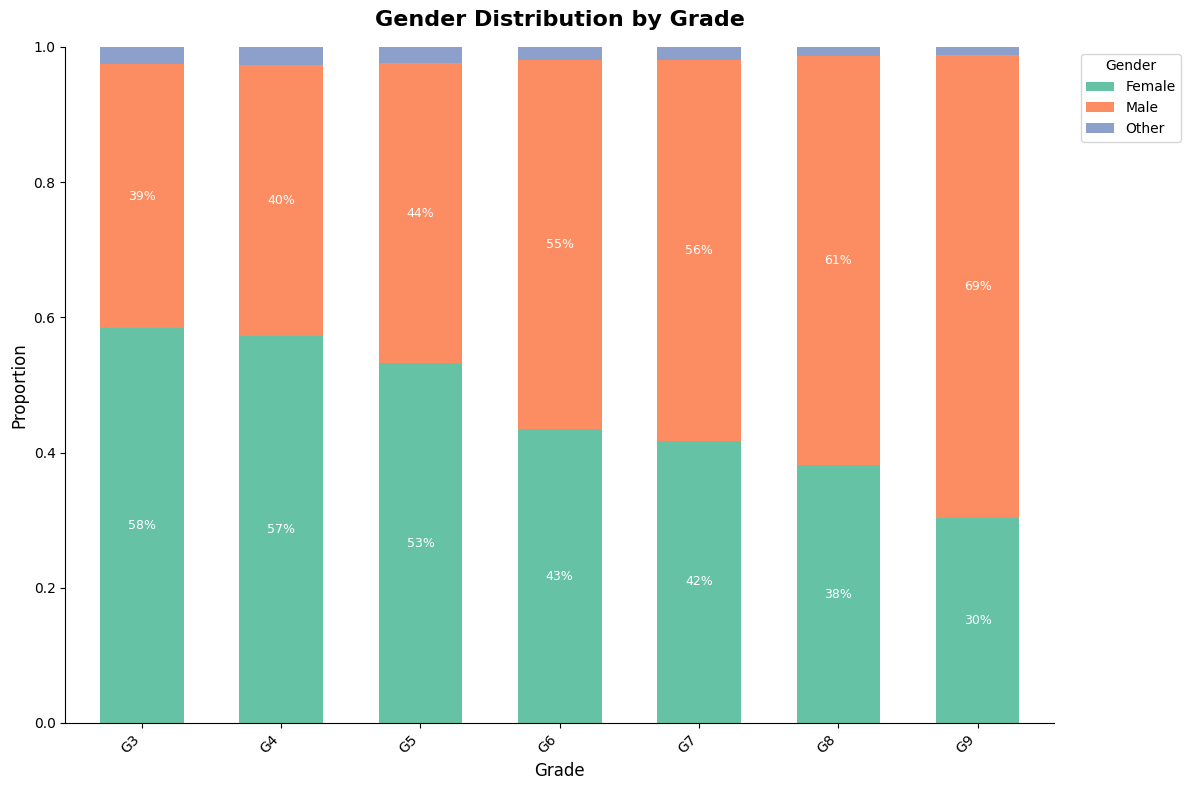

In [60]:
gender_prop = pd.crosstab(df['grade'], df['gender'], normalize='index')

fig, ax = plt.subplots(figsize=(12,8))

# Softer professional colors
colors = sns.color_palette("Set2", len(gender_prop))

gender_prop.plot(
    kind='bar',
    stacked=True,
    color= colors,
    ax=ax,
    width=0.6
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.0f}%" if v > 0.05 else "" for v in container.datavalues],
        label_type='center',
        fontsize=9,
        color='white'
    )

ax.set_title("Gender Distribution by Grade", fontsize=16, weight='bold', pad = 15)
ax.set_ylabel("Proportion",fontsize=12)
ax.set_xlabel("Grade", fontsize=12)
ax.set_ylim(0,1)
# Move legend outside
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha='right', fontsize=10)

sns.despine()  # removes top/right border
plt.tight_layout()
plt.show()

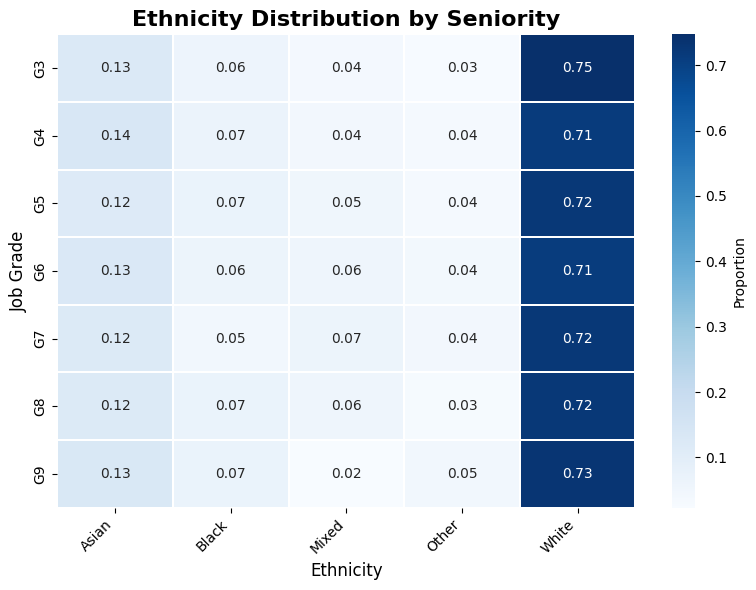

In [45]:
eth_prop = pd.crosstab(df['grade'], df['ethnicity'], normalize='index')
plt.figure(figsize=(8,6))
sns.heatmap(eth_prop, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'Proportion'}, linewidths=0.1)

# Titles and labels
plt.title("Ethnicity Distribution by Seniority", fontsize=16, weight='bold')
plt.xlabel("Ethnicity", fontsize=12)
plt.ylabel("Job Grade", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

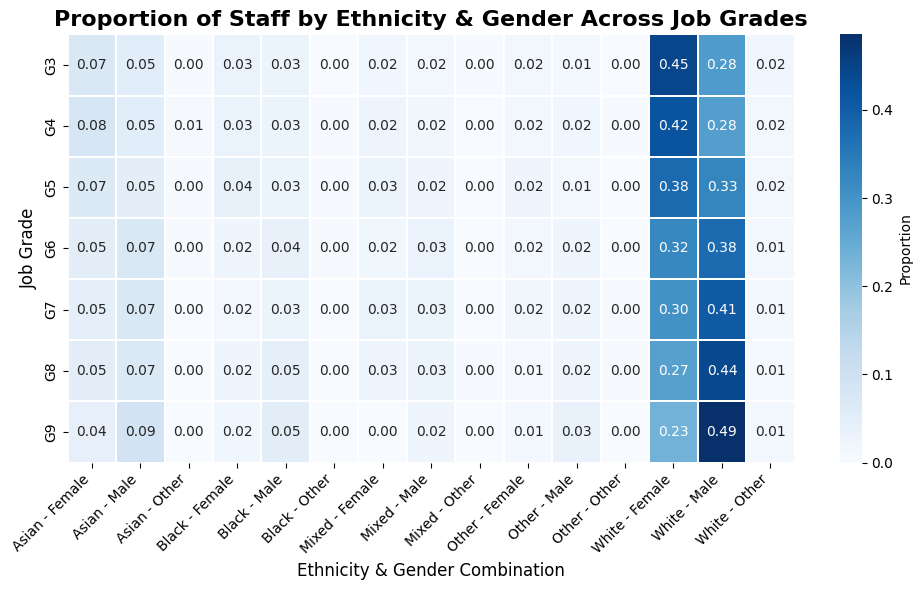

In [46]:
# combing both ethinicity and gender
df['eth_gender'] = df['ethnicity'] + ' - ' + df['gender']
ct = pd.crosstab(df['grade'], df['eth_gender'], normalize='index')

plt.figure(figsize=(10,6))

# Use a good sequential colormap
sns.heatmap(ct, annot=True, fmt=".2f", cmap='Blues', cbar_kws={'label': 'Proportion'}, linewidths=0.1)

# Titles and labels
plt.title("Proportion of Staff by Ethnicity & Gender Across Job Grades", fontsize=16, weight='bold')
plt.xlabel("Ethnicity & Gender Combination", fontsize=12)
plt.ylabel("Job Grade", fontsize=12)

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


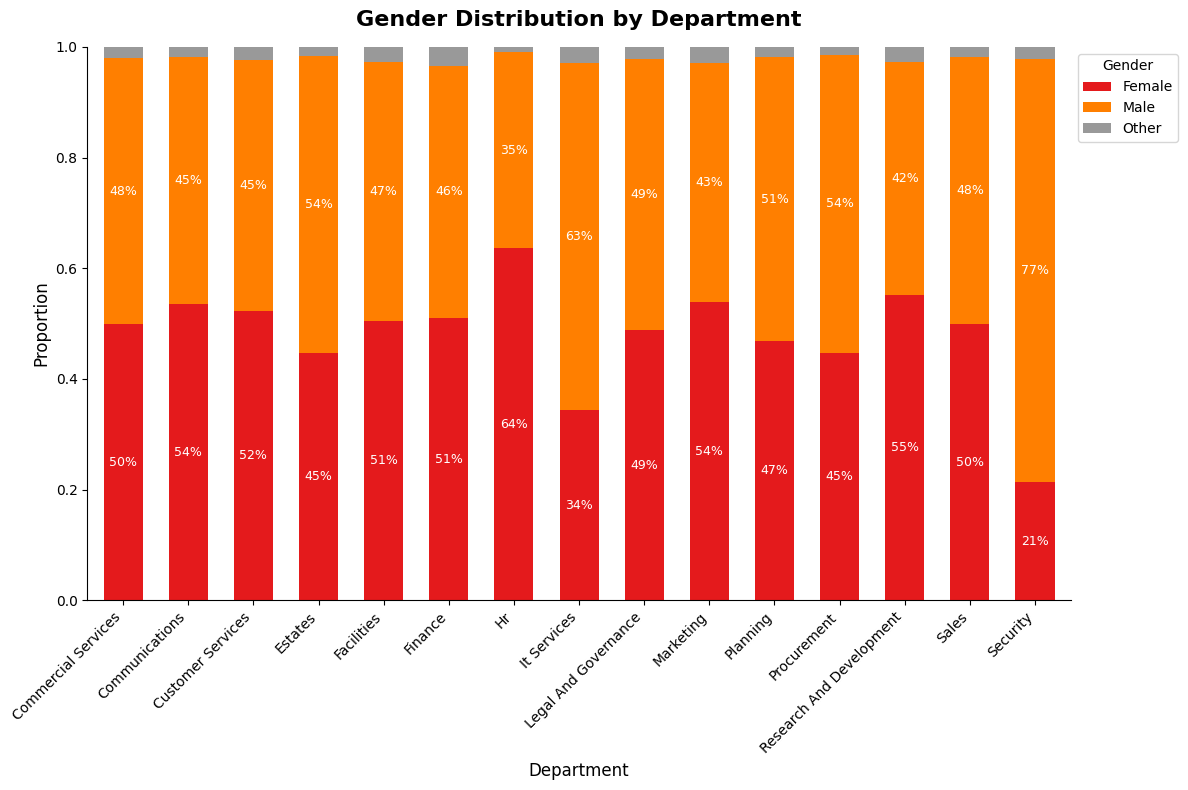

In [57]:
# Gender distribution per department (proportion)
gender_dep = pd.crosstab(df['department'], df['gender'], normalize='index')

fig, ax = plt.subplots(figsize=(12,8))


gender_dep.plot(
    kind='bar',
    stacked=True,
    colormap='Set1',
    ax=ax,
    width=0.6
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.0f}%" if v > 0.05 else "" for v in container.datavalues],
        label_type='center',
        fontsize=9,
        color='white'
    )
ax.set_title("Gender Distribution by Department", fontsize=16, weight='bold', pad = 15)
ax.set_ylabel("Proportion",fontsize=12)
ax.set_xlabel("Department", fontsize=12)
ax.set_ylim(0,1)

# Move legend outside
ax.legend(title="Gender", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=45, ha='right', fontsize=10)

sns.despine()  # removes top/right border
plt.tight_layout()
plt.show()

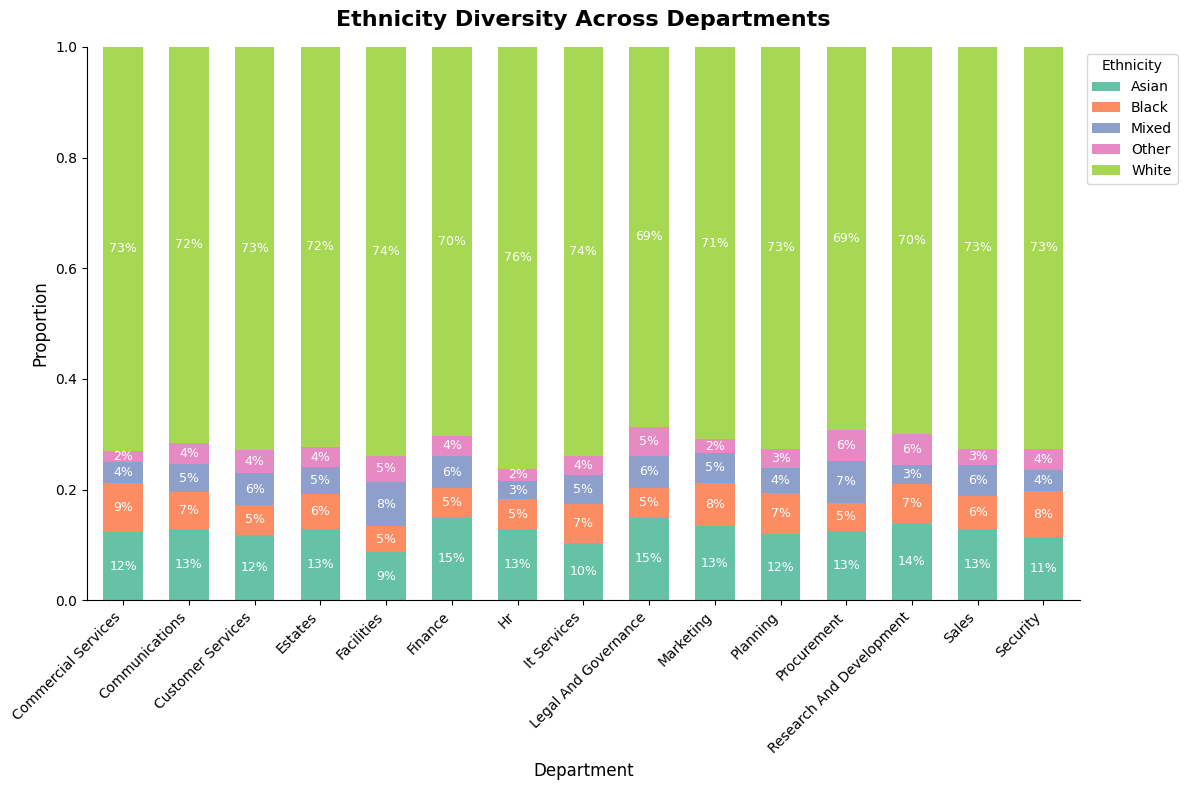

In [54]:
Ethnic_depart = pd.crosstab(df['department'], df['ethnicity'], normalize='index')

fig, ax = plt.subplots(figsize=(12,8))
colors = sns.color_palette("Set2", len(Ethnic_depart))

Ethnic_depart.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.6,
    color= colors    
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v*100:.0f}%" if v > 0 else "" for v in container.datavalues],
        label_type='center',
        fontsize=9,
        color = 'white'
    )
ax.set_title("Ethnicity Diversity Across Departments", fontsize=16, weight='bold', pad = 15)
ax.set_ylabel("Proportion",fontsize=12)
ax.set_xlabel("Department", fontsize=12)
ax.set_ylim(0,1)

# Move legend outside
ax.legend(title="Ethnicity", bbox_to_anchor=(1, 1), loc="upper left")
plt.xticks(rotation=45, ha='right', fontsize=10)

sns.despine()  # removes top/right border
plt.tight_layout()
plt.show()

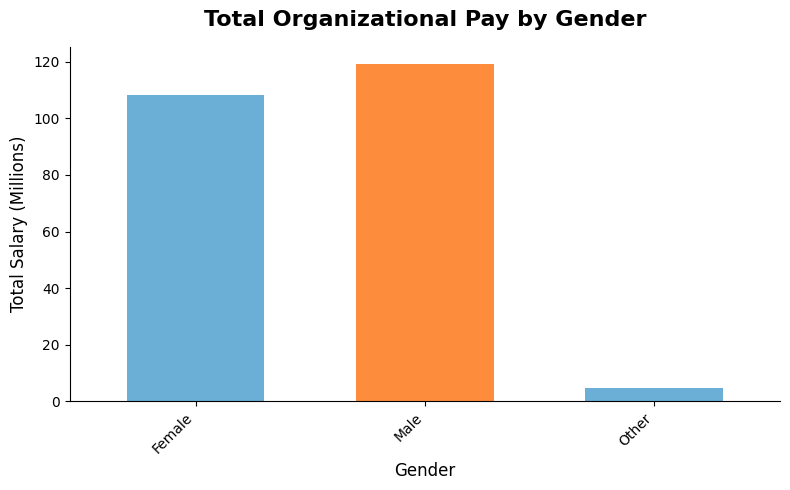

In [55]:
Gender_salary = df.groupby('gender')['salary'].sum()/ 1_000_000
fig, ax = plt.subplots(figsize=(8,5))


Gender_salary.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.6,
    color=['#6BAED6', '#FD8D3C']

)   

plt.title("Total Organizational Pay by Gender", fontsize=16, weight='bold', pad= 15)
plt.ylabel("Total Salary (Millions)", fontsize = 12)
plt.xlabel("Gender",  fontsize = 12)

plt.xticks(rotation=45, ha='right', fontsize=10)

sns.despine()  # removes top/right border
plt.tight_layout()
plt.show()


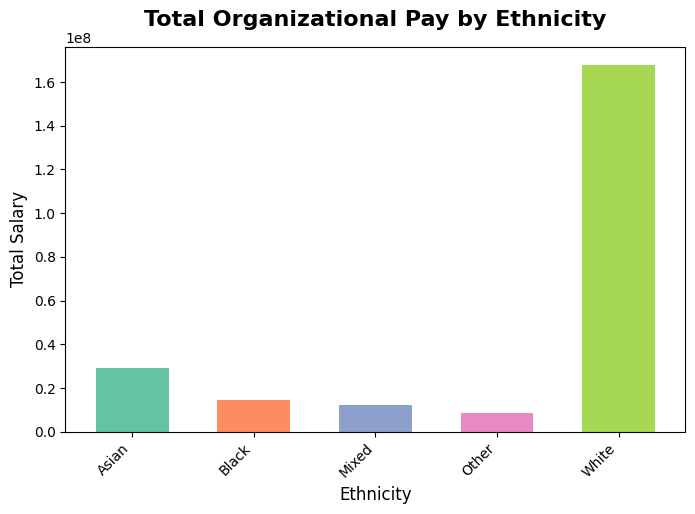

In [53]:
Ethnicity_salary = df.groupby('ethnicity')['salary'].sum()


fig, ax = plt.subplots(figsize=(8,5))

colors = sns.color_palette("Set2", len(Ethnicity_salary))
Ethnicity_salary.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.6,
    color= colors

    
)

plt.title("Total Organizational Pay by Ethnicity", fontsize=16, weight='bold', pad= 15)
plt.ylabel("Total Salary", fontsize = 12)
plt.xlabel("Ethnicity", fontsize = 12)
plt.xticks(rotation=45, ha='right')
plt.show()